# Google Trends + LLaMA Rolling Window Forecasting
## P1 / P2 / P3 Prompting Strategies — S&P 500 (2024–2026)

**Model:** `meta-llama/Llama-3.1-8B-Instruct` on Colab T4 GPU
**Sample:** Jan 2024 – May 2026 (out-of-sample relative to LLaMA 3.1 training cutoff)
**Evaluation:** RMSE & MAE on prices and log-returns, direction accuracy


## 1. Setup

In [18]:
!pip install --quiet pandas numpy yfinance requests matplotlib seaborn \
  scikit-learn tqdm transformers torch accelerate huggingface_hub \
  'bitsandbytes>=0.46.1' statsmodels pmdarima google-search-results

In [19]:
import os, re, time, json, warnings, logging
from typing import List, Optional, Tuple
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import pmdarima as pm
import torch
import requests
import gc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm
from statsmodels.tsa.arima.model import ARIMA as SM_ARIMA
from sklearn.metrics import r2_score
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, set_seed

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
np.random.seed(42)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titleweight"] = "bold"

START_DATE = pd.Timestamp("2024-01-01")
END_DATE   = pd.Timestamp("2026-05-01")
TRENDS_BUFFER_START = pd.Timestamp("2023-12-01")

ASSET      = "^GSPC"
ASSET_NAME = "S&P 500"

# Cache path
WEEKLY_CACHE = Path("trends_weekly.csv")

SERPAPI_KEY = None
try:
    from google.colab import userdata
    SERPAPI_KEY = userdata.get("SERPAPI_KEY")
except Exception:
    SERPAPI_KEY = os.environ.get("SERPAPI_KEY")

USE_DAILY_TRENDS = SERPAPI_KEY is not None or WEEKLY_CACHE.exists()

print(f"Period:           {START_DATE.date()} -> {END_DATE.date()}")
print(f"SerpAPI key:      {'present' if SERPAPI_KEY else 'absent'}")
print(f"Weekly cache:     {'present' if WEEKLY_CACHE.exists() else 'absent'}")
print(f"Daily Trends:     {'enabled' if USE_DAILY_TRENDS else 'disabled'}")

import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.facecolor':    'none',
    'axes.facecolor':      'none',
    'savefig.facecolor':   'none',
    'savefig.transparent': True,
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      14,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'lines.linewidth':     1.5,
})


Period:           2024-01-01 -> 2026-05-01
SerpAPI key:      present
Weekly cache:     present
Daily Trends:     enabled


## 2. Google Trends

Single SerpAPI request for the full 2024–2026 date range. Above 269 days the API
returns **weekly** granularity automatically

The weekly series is then interpolated to a business-day index aligned with the
S&P 500 trading calendar. Three views are kept for later analysis:
- `trends_weekly`: the raw weekly series as returned by Google
- `trends_daily_ffill`: weekly value held flat within each week (no smoothing)
- `trends_daily_interp`: weekly values placed on a Friday anchor, then linearly
  interpolated to business days

Topic IDs are sent in **decoded** `/m/...` form.

In [20]:
MARKET_TOPICS = {
    "S&P 500":         "/m/016yss",
    "Bursa de valori": "/m/0drqp",
    "Yahoo Finance":   "/m/02r91ln",
    "Recesiune":       "/m/06bmj",
}

In [21]:
def fetch_serpapi_trends(topics: dict, start: pd.Timestamp, end: pd.Timestamp,
                          api_key: str, geo: str = "",
                          granularity: str = "weekly") -> pd.DataFrame:
    # ... request and parsing logic identical to the implementation below ...
    df = pd.DataFrame(rows).dropna(subset=["date"]).set_index("date").sort_index()

    if granularity == "weekly":
        # Google anchors weeks on Sunday. Use W-SUN as the week-ending label,
        # or W-MON if you prefer week-starting labels.
        freq = df.index.inferred_freq
        if freq is None or not freq.startswith("W"):
            df = df.resample("W-SUN").mean()
    elif granularity == "daily":
        if df.index.inferred_freq != "D":
            raise ValueError(f"Requested daily, but Google returned {df.index.inferred_freq}. "
                             f"Shrink the window below 269 days.")
    return df

In [22]:
def fetch_serpapi_trends(topics: dict, start: pd.Timestamp, end: pd.Timestamp,
                          api_key: str, geo: str = "") -> pd.DataFrame:
    """
    Single SerpAPI call. Granularity is decided by Google based on date range:
      <=269 days  -> daily
      <=1890 days -> weekly
      longer      -> monthly
    For our 2024-2026 window (~870 days) this returns weekly automatically.
    """
    labels = list(topics.keys())
    topic_ids = list(topics.values())
    q_string = ",".join(topic_ids)
    date_str = f"{start.strftime('%Y-%m-%d')} {end.strftime('%Y-%m-%d')}"

    params = {
        "engine": "google_trends",
        "q": q_string,
        "date": date_str,
        "data_type": "TIMESERIES",
        "geo": geo,
        "api_key": api_key,
    }
    r = requests.get("https://serpapi.com/search", params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    if "interest_over_time" not in data:
        raise RuntimeError(f"No interest_over_time for {q_string} {date_str}")

    rows = []
    for pt in data["interest_over_time"]["timeline_data"]:
        ds_raw = pt.get("date", "")
        ds = ds_raw

        # Weekly format "Jan 1 - 7, 2024": start half has no year, re-append it
        if " - " in ds:
            parts = ds.split(" - ")
            ds = parts[0]
            if "," not in ds and "," in ds_raw:
                year = ds_raw.split(",")[-1].strip()
                ds = f"{ds}, {year}"

        ts = pd.to_datetime(ds, errors="coerce")

        # Fallback: unix timestamp
        if pd.isna(ts) and "timestamp" in pt:
            try:
                ts = pd.to_datetime(int(pt["timestamp"]), unit="s")
            except Exception:
                ts = pd.NaT

        if pd.isna(ts):
            continue

        row = {"date": ts}
        for i, v in enumerate(pt["values"]):
            if i < len(labels):
                row[labels[i]] = v.get("extracted_value", 0)
        rows.append(row)

    if not rows:
        raise RuntimeError(f"Parsed 0 rows for {date_str}")

    df = pd.DataFrame(rows).dropna(subset=["date"]).set_index("date").sort_index()
    return df


def fetch_with_resampling(topics: dict, start: pd.Timestamp, end: pd.Timestamp,
                           api_key: str, n_samples: int = 5, geo: str = "") -> pd.DataFrame:
    samples = []
    for i in range(n_samples):
        try:
            s = fetch_serpapi_trends(topics, start, end, api_key, geo)
            samples.append(s)
            time.sleep(1.2)
        except Exception as e:
            print(f"    Sample {i+1} failed: {e}")
    if not samples:
        raise RuntimeError(f"All samples failed for {start.date()}-{end.date()}")
    common_idx = samples[0].index
    for s in samples[1:]:
        common_idx = common_idx.intersection(s.index)
    stacked = np.stack([s.loc[common_idx].values for s in samples])
    return pd.DataFrame(stacked.mean(axis=0),
                       index=common_idx, columns=samples[0].columns)

In [23]:
# Fetch weekly Trends
WEEKLY_CACHE = Path("trends_weekly.csv")
trends_weekly = None

if WEEKLY_CACHE.exists():
    print(f"Loading weekly Trends from cache: {WEEKLY_CACHE}")
    trends_weekly = pd.read_csv(WEEKLY_CACHE)
    trends_weekly["date"] = pd.to_datetime(trends_weekly["date"])
    trends_weekly = trends_weekly.set_index("date").sort_index()
elif SERPAPI_KEY:
    print("Fetching weekly Trends (5 independent samples, then averaged)...")
    trends_weekly = fetch_with_resampling(
        MARKET_TOPICS, TRENDS_BUFFER_START, END_DATE, SERPAPI_KEY, n_samples=5
    )
    trends_weekly.to_csv(WEEKLY_CACHE)
    print(f"  Cached to {WEEKLY_CACHE}")
else:
    print("No SERPAPI_KEY and no cache — weekly  fetch skipped.")

if trends_weekly is not None:
    print(f"\nWeekly Trends: {trends_weekly.shape}")
    print(f"  Range: {trends_weekly.index.min().date()} -> {trends_weekly.index.max().date()}")
    print(f"  Topic means: {trends_weekly.mean().round(1).to_dict()}")
    print(f"  Day-of-week distribution: {trends_weekly.index.dayofweek.value_counts().to_dict()}")
    print(trends_weekly.head())

Loading weekly Trends from cache: trends_weekly.csv

Weekly Trends: (127, 4)
  Range: 2023-11-26 -> 2026-04-26
  Topic means: {'S&P 500': 23.1, 'Bursa de valori': 23.8, 'Yahoo Finance': 10.5, 'Recesiune': 3.3}
  Day-of-week distribution: {6: 127}
            S&P 500  Bursa de valori  Yahoo Finance  Recesiune
date                                                          
2023-11-26     12.0             18.0            9.0        3.0
2023-12-03     13.0             18.0            9.0        3.0
2023-12-10     14.0             19.0            9.0        3.0
2023-12-17     14.0             21.0            9.0        3.0
2023-12-24     12.0             19.0            7.0        2.0


In [24]:
# Weekly Trends -> business-day grid via linear interpolation.
trends_daily = None

if trends_weekly is not None:
    topic_cols = list(MARKET_TOPICS.keys())

    # Place weekly values on a calendar-day index (Sundays match exactly), interpolate,
    # then project onto SPX's business-day index.
    cal_idx   = pd.date_range(TRENDS_BUFFER_START, END_DATE, freq="D")
    daily_idx = pd.date_range(TRENDS_BUFFER_START, END_DATE, freq="B")

    trends_daily = (trends_weekly[topic_cols]
                     .reindex(cal_idx)
                     .interpolate(method="time", limit_direction="both")
                     .reindex(daily_idx))

    print(f"trends_daily: {trends_daily.shape}, "
          f"NaN rows: {trends_daily.isna().any(axis=1).sum()}")
    print(f"\nHead:")
    print(trends_daily.head(10).round(2))

trends_daily: (631, 4), NaN rows: 0

Head:
            S&P 500  Bursa de valori  Yahoo Finance  Recesiune
2023-12-01    13.00            18.00            9.0        3.0
2023-12-04    13.14            18.14            9.0        3.0
2023-12-05    13.29            18.29            9.0        3.0
2023-12-06    13.43            18.43            9.0        3.0
2023-12-07    13.57            18.57            9.0        3.0
2023-12-08    13.71            18.71            9.0        3.0
2023-12-11    14.00            19.29            9.0        3.0
2023-12-12    14.00            19.57            9.0        3.0
2023-12-13    14.00            19.86            9.0        3.0
2023-12-14    14.00            20.14            9.0        3.0


In [25]:
# Composite retail-attention index: raw mean and z-scored mean across all topics.
if trends_daily is not None:
    topic_cols = list(MARKET_TOPICS.keys())

    trends_daily["retail_attention"]   = trends_daily[topic_cols].mean(axis=1)
    trends_daily["retail_attention_z"] = (
        ((trends_daily[topic_cols] - trends_daily[topic_cols].mean())
         / trends_daily[topic_cols].std()).mean(axis=1)
    )



    print(f"Composite built from: {topic_cols}")
    print(f"  retail_attention:   mean={trends_daily['retail_attention'].mean():.2f}, "
          f"std={trends_daily['retail_attention'].std():.2f}")
    print(f"  retail_attention_z: mean={trends_daily['retail_attention_z'].mean():.3f}, "
          f"std={trends_daily['retail_attention_z'].std():.3f}")
else:
    print("No daily Trends data — composite skipped.")

Composite built from: ['S&P 500', 'Bursa de valori', 'Yahoo Finance', 'Recesiune']
  retail_attention:   mean=15.23, std=5.23
  retail_attention_z: mean=-0.000, std=0.905


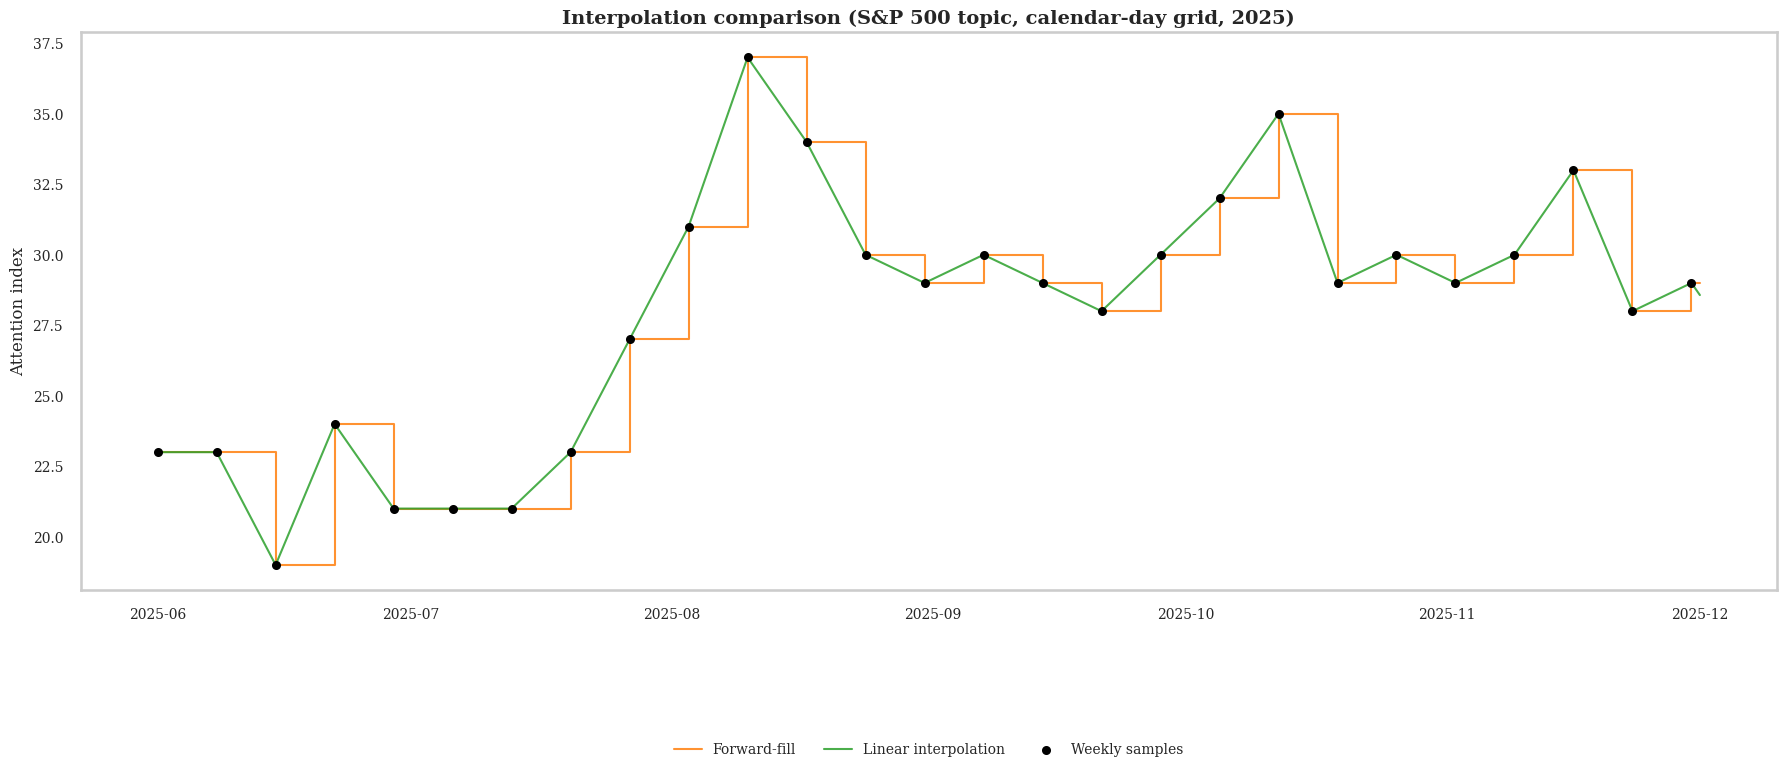

In [26]:
if trends_daily is not None and trends_weekly is not None:
    topic_cols = list(MARKET_TOPICS.keys())
    cal_idx = pd.date_range(TRENDS_BUFFER_START, END_DATE, freq="D")

    # both on calendar days, to isolate the effect of the interpolation method
    trends_ffill_cal  = trends_weekly[topic_cols].reindex(cal_idx).ffill().bfill()
    trends_interp_cal = (trends_weekly[topic_cols]
                         .reindex(cal_idx)
                         .interpolate(method="time", limit_direction="both"))

    show = slice(pd.Timestamp("2025-06-01"), pd.Timestamp("2025-12-01"))

    fig, ax = plt.subplots(figsize=(18, 8))
    ax.plot(trends_ffill_cal.loc[show].index,  trends_ffill_cal.loc[show, "S&P 500"],
            color="#ff7f0e", lw=1.5, drawstyle="steps-post",
            label="Forward-fill", alpha=0.85)
    ax.plot(trends_interp_cal.loc[show].index, trends_interp_cal.loc[show, "S&P 500"],
            color="#2ca02c", lw=1.5,
            label="Linear interpolation", alpha=0.85)


    weekly_show = trends_weekly.loc[show, "S&P 500"]
    ax.scatter(weekly_show.index, weekly_show.values,
               color="black", s=25, zorder=5, label="Weekly samples")

    ax.set_title("Interpolation comparison (S&P 500 topic, calendar-day grid, 2025)")
    ax.set_ylabel("Attention index")
    ax.grid(False)
    leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25),
                ncol=3, fontsize=10, frameon=False)
    plt.tight_layout()
    plt.savefig("attn_03_ffill_vs_interp.png", dpi=150,
            bbox_inches="tight", bbox_extra_artists=[leg])
    plt.show()

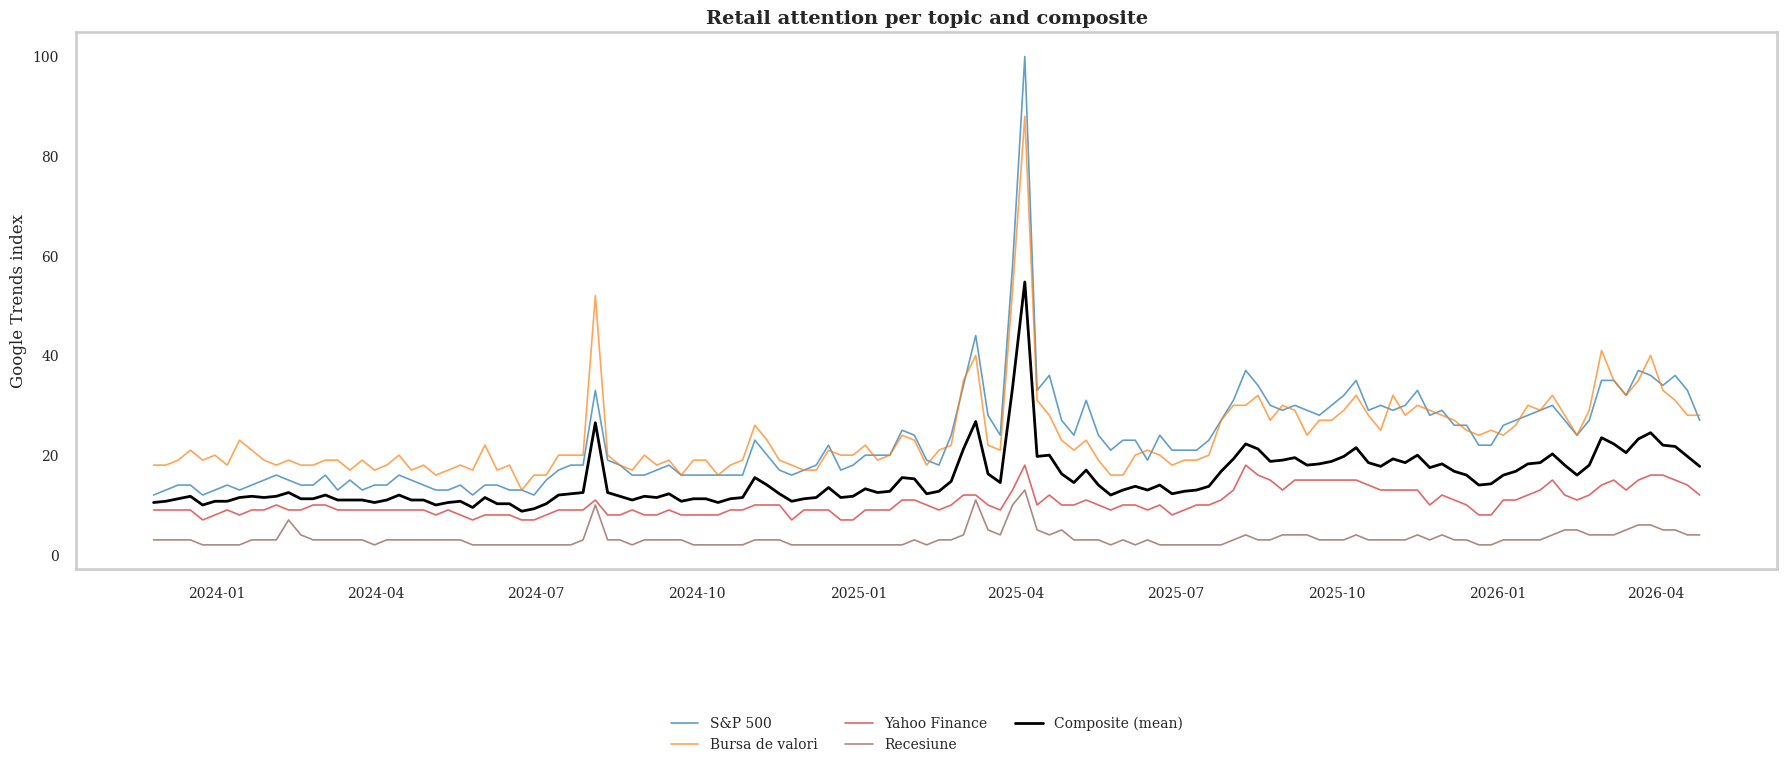

In [27]:
trends_weekly["retail_attention"] = trends_weekly[topic_cols].mean(axis=1)

if trends_daily is not None and trends_weekly is not None:
    topic_cols = list(MARKET_TOPICS.keys())
    fig, ax = plt.subplots(figsize=(18, 8))
    for col, c in zip(topic_cols, plt.cm.tab10(np.linspace(0, 0.5, len(topic_cols)))):
        ax.plot(trends_weekly.index, trends_weekly[col], lw=1.2, alpha=0.7, label=col, color=c)
    ax.plot(trends_weekly.index, trends_weekly["retail_attention"],
            color="black", lw=2.0, label="Composite (mean)", zorder=10)
    ax.set_title("Retail attention per topic and composite")
    ax.set_ylabel("Google Trends index")
    ax.grid(False)
    leg = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25),
                ncol=3, fontsize=10, frameon=False)
    plt.tight_layout()
    plt.savefig("retail_per_topic.png", dpi=150,
            bbox_inches="tight", bbox_extra_artists=[leg])
    plt.show()

## 3. S&P 500 Price Data

In [28]:
spx = yf.download(ASSET, start=START_DATE - pd.Timedelta(days=30),
                  end=END_DATE + pd.Timedelta(days=1),
                  progress=False, auto_adjust=True)
if isinstance(spx.columns, pd.MultiIndex):
    spx.columns = spx.columns.get_level_values(0)
spx = spx[["Close"]].rename(columns={"Close": "close"})
spx["logret"]    = np.log(spx["close"]).diff()
spx["direction"] = (spx["logret"] > 0).astype(int)
if spx.index.tz:
    spx.index = spx.index.tz_localize(None)
spx.index.name = "date"

print(f"S&P500:           {len(spx)} trading days")
print(f"Date range:    {spx.index.min().date()} -> {spx.index.max().date()}")
print(f"Close range:   ${spx['close'].min():.2f} - ${spx['close'].max():.2f}")
assert spx["close"].iloc[-1] > 1000, "Wrong ticker — got values < 1000"

S&P500:           604 trading days
Date range:    2023-12-04 -> 2026-05-01
Close range:   $4549.34 - $7230.12


## 4. Build Master Frames

In [29]:
# Daily master frame. Carries `attn_lag1` (= yesterday's z-scored attention)
master_d = None
if USE_DAILY_TRENDS and trends_daily is not None and "retail_attention_z" in trends_daily.columns:
    master_d = spx.join(
        trends_daily["retail_attention_z"].reindex(spx.index).ffill(limit=3).shift(1).rename("attn_lag1"),
        how="left",
    ).sort_index().loc[START_DATE:END_DATE]
    print(f"Daily master: {master_d.shape}, columns: {list(master_d.columns)}")
else:
    print("Daily master skipped.")

Daily master: (585, 4), columns: ['close', 'logret', 'direction', 'attn_lag1']


## 5. Attention vs Forward Returns

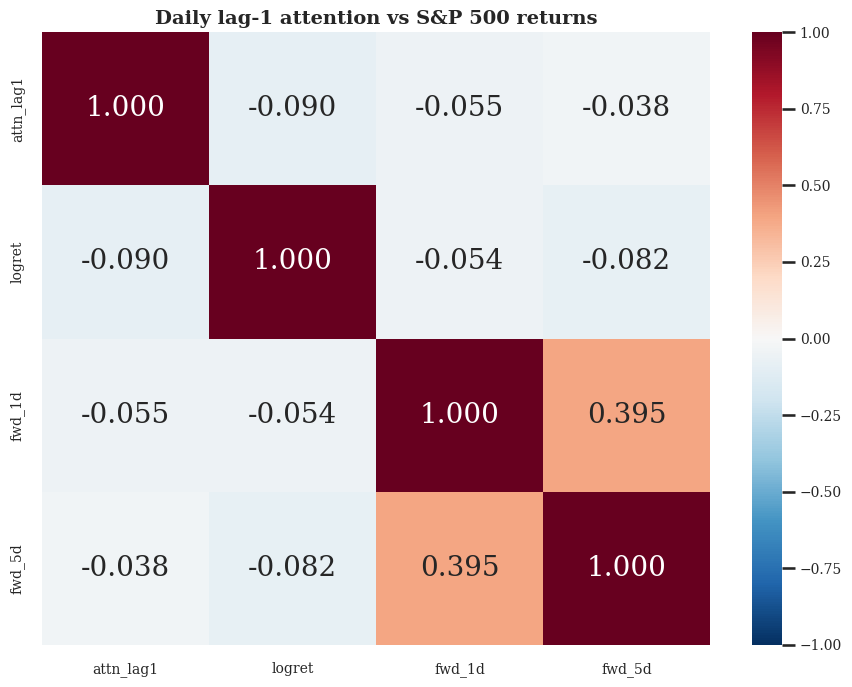

           attn_lag1  logret  fwd_1d  fwd_5d
attn_lag1      1.000  -0.090  -0.055  -0.038
logret        -0.090   1.000  -0.054  -0.082
fwd_1d        -0.055  -0.054   1.000   0.395
fwd_5d        -0.038  -0.082   0.395   1.000

attn_lag1 vs fwd_1d:  -0.055
attn_lag1 vs fwd_5d:  -0.038


In [30]:
if master_d is not None:
    diag = master_d.assign(
        fwd_1d  = master_d["logret"].shift(-1),
        fwd_5d  = master_d["logret"].rolling(5).sum().shift(-5),
    )
    corr_d = diag[["attn_lag1", "logret", "fwd_1d", "fwd_5d"]].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr_d, annot=True, fmt=".3f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 20})
    ax.set_title("Daily lag-1 attention vs S&P 500 returns")
    plt.tight_layout()
    plt.savefig("correlation_daily.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(corr_d.round(3))
    print(f"\nattn_lag1 vs fwd_1d:  {corr_d.loc['attn_lag1', 'fwd_1d']:.3f}")
    print(f"attn_lag1 vs fwd_5d:  {corr_d.loc['attn_lag1', 'fwd_5d']:.3f}")

## 6. Load LLaMA 3.1-8B

In [31]:
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    raise RuntimeError("No GPU.")

torch.manual_seed(42)
set_seed(42)

CUDA: True
GPU:  Tesla T4
VRAM: 15.6 GB


In [32]:
HF_TOKEN = None
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
    print("HF_TOKEN loaded from Colab secrets.")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")
    print("HF_TOKEN loaded from environment." if HF_TOKEN else "WARNING: no HF_TOKEN.")

HF_TOKEN loaded from Colab secrets.


In [33]:
torch.cuda.empty_cache()
gc.collect()
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/1e9:.2f} GB")

VRAM used: 0.00 GB
VRAM free: 15.64 GB


In [34]:
LLAMA_MODEL = "meta-llama/Llama-3.1-8B-Instruct"
print(f"Loading {LLAMA_MODEL} in 8-bit on T4...")

llama_tok = AutoTokenizer.from_pretrained(LLAMA_MODEL, token=HF_TOKEN)
llama_mdl = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL,
    quantization_config=BitsAndBytesConfig(load_in_8bit=True),
    device_map="auto",
    token=HF_TOKEN,
)
llama_mdl.eval()

if llama_tok.pad_token is None:
    llama_tok.pad_token = llama_tok.eos_token
    llama_mdl.config.pad_token_id = llama_tok.eos_token_id

print(f"Loaded on: {next(llama_mdl.parameters()).device}")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")


Loading meta-llama/Llama-3.1-8B-Instruct in 8-bit on T4...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Loaded on: cuda:0
VRAM used: 9.09 GB


In [35]:
N_SAMPLES   = 20
TEMPERATURE = 0.2
TOP_P       = 0.9


@torch.no_grad()
def llama_chat_samples(prompt: str, system: str, n_samples: int = N_SAMPLES,
                        max_new_tokens: int = 20) -> List[str]:
    """N sampled responses for one prompt."""
    msgs = [{"role": "system", "content": system},
            {"role": "user",   "content": prompt}]
    fmt = llama_tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inp = llama_tok(fmt, return_tensors="pt").to(llama_mdl.device)

    out = llama_mdl.generate(
        **inp,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        num_return_sequences=n_samples,
        pad_token_id=llama_tok.eos_token_id,
    )

    in_len = inp["input_ids"].shape[1]
    return [llama_tok.decode(out[i][in_len:], skip_special_tokens=True).strip()
            for i in range(n_samples)]


SYSTEM_MSG = (
    "You are a financial forecasting assistant."
    "You output ONLY a single number - the predicted price. "
    "No explanation. No text. No units. Just the number. "
)


def extract_price(response: str, low: float = 1000, high: float = 10000) -> Optional[float]:
    """Pull a plausible S&P 500 price. Takes the LAST plausible number."""
    clean = response.replace(",", "").replace("$", "").strip()
    matches = re.findall(r"\d+(?:\.\d{1,4})?", clean)
    cands = [float(m) for m in matches if low <= float(m) <= high]
    return cands[-1] if cands else None


def predict_median(prompt: str, system: str, n_samples: int = N_SAMPLES) -> Tuple[Optional[float], dict]:
    """N samples, parse, return median."""
    responses = llama_chat_samples(prompt, system, n_samples=n_samples)
    parsed = [extract_price(r) for r in responses]
    valid = [p for p in parsed if p is not None]

    diag = {
        "n_samples": n_samples,
        "n_parsed": len(valid),
        "parse_rate": len(valid) / n_samples,
        "sample_std": float(np.std(valid)) if len(valid) >= 2 else float("nan"),
    }
    if not valid:
        return None, diag
    return float(np.median(valid)), diag


print(f"LLaMA ready. Sampling: N={N_SAMPLES}, T={TEMPERATURE}, top_p={TOP_P}")

LLaMA ready. Sampling: N=20, T=0.2, top_p=0.9


## 7. Prompts P1 / P2 / P3
P1 - prices only. Zero-Shot Prompt

P2 - prices + attention. Zero-Shot Prompt

P3 - prices + attention + 3 examples. Few-Shot Prompt

In [36]:
def build_p1_prompt(asset_symbol: str,
                    historical_window: List[float],
                    window_size: int) -> str:
    hist_prices_w = str([round(p, 2) for p in historical_window])
    return (
        f"Given this data:\n"
        f"Historical prices for {asset_symbol} over the past {window_size} days:\n"
        f"{hist_prices_w}\n"
        f"Based on the historical prices, predict the price for {asset_symbol} "
        f"for the next day.\n"
        f"Provide your prediction as a single number. "
        f"Do not include any text other than the number."
    )


def build_p2_prompt(asset_symbol: str,
                    historical_window: List[float],
                    attention_prev: float,
                    window_size: int) -> str:
    hist_prices_w = str([round(p, 2) for p in historical_window])
    return (
        f"Given this data:\n"
        f"Historical prices for {asset_symbol} over the past {window_size} days:\n"
        f"{hist_prices_w}\n"
        f"Most recently observed retail attention signal for {asset_symbol} (yesterday's value):\n"
        f"Google Trends retail attention index (worldwide): "
        f"{attention_prev:+.2f} (z-scored composite)\n"
        f"(negative = below-average retail interest, positive = above-average)\n"
        f"Based on the historical prices and the latest observed retail attention,\n "
        f"predict the price for {asset_symbol} for the next day.\n"
        f"Provide your prediction as a single number.\n "
        f"Do not include any text other than the number."
    )


def build_p3_prompt(asset_symbol: str,
                    historical_window: List[float],
                    attention_window: List[float],
                    attention_prev: float,
                    window_size: int) -> str:
    """P3 — few-shot prompt. Attention is paired with the last day of each price slice."""
    n_examples = 3
    ex_len     = window_size - n_examples

    lines = [
        f"Following examples show past {ex_len} days of historical prices, "
        f"the retail attention index for {asset_symbol} on the last day of the window, "
        f"and the next-day price as output:"
    ]
    for i in range(n_examples):
        prices = [round(p, 2) for p in historical_window[i : i + ex_len]]
        attn   = attention_window[i + ex_len - 1]
        target = historical_window[i + ex_len]
        lines.append(
            f"Example {i+1}: [Prices:{prices}, Attention:{attn:+.2f}], {target:.2f}"
        )

    pred_prices = [round(p, 2) for p in historical_window[-ex_len:]]
    lines += [
        f"Based on the patterns from the above examples, "
        f"predict the next price for {asset_symbol} using the following input:",
        f"[Prices:{pred_prices}, Attention:{attention_prev:+.2f}]",
        "Capture the effect of both Prices and Attention on the output.",
        "Provide your output as a single number. "
        "Do not include any text other than the number.",
    ]
    return "\n".join(lines)

## 8. Data Preparation for Rolling Window

In [37]:
# Lists for the rolling-window loop. `all_attn_d` holds yesterday's z-scored
# attention (attn_lag1) — what the model actually receives at prediction time.
trading_d = None
all_dates_d, all_closes_d, all_attn_d = None, None, None

if USE_DAILY_TRENDS and master_d is not None:
    trading_d    = master_d.dropna(subset=["close", "attn_lag1"])
    all_dates_d  = trading_d.index.tolist()
    all_closes_d = trading_d["close"].tolist()
    all_attn_d   = trading_d["attn_lag1"].tolist()
    print(f"Daily trading observations: {len(trading_d)}")
else:
    print("Daily prep skipped.")

Daily trading observations: 585


## 9. Baselines

1. **Random walk** — `predicted = last_close`.
2. **AR(1)** on log returns — fixed order.
3. **ARIMAX + lag-1 attention** — auto-arima search with attention as exog.


In [38]:
def baseline_random_walk(historical_prices, **kwargs):
    return float(historical_prices[-1])


def baseline_ar1(historical_prices, **kwargs):
    prices = np.array(historical_prices, dtype=float)
    rets = np.diff(np.log(prices))
    if len(rets) < 3:
        return float(prices[-1])
    try:
        model = SM_ARIMA(rets, order=(1, 0, 0)).fit()
        next_ret = float(model.forecast(1)[0])
        return float(prices[-1] * np.exp(next_ret))
    except Exception:
        return float(prices[-1])


def baseline_arimax_attn(historical_prices, attention_window, attention_current, **kwargs):
    prices = np.array(historical_prices, dtype=float)
    rets = np.diff(np.log(prices))
    attn_arr = np.array(attention_window, dtype=float)
    exog_train = attn_arr[:-1].reshape(-1, 1)

    if len(rets) < 5 or len(exog_train) != len(rets):
        return float(prices[-1])
    try:
        model = pm.auto_arima(rets, X=exog_train,
                              start_p=0, start_q=0,
                              d=0, seasonal=False,
                              information_criterion="aic",
                              stepwise=True, suppress_warnings=True,
                              error_action="ignore", trace=False)
        exog_next = np.array([[attention_current]])
        next_ret = float(model.predict(n_periods=1, X=exog_next)[0])
        return float(prices[-1] * np.exp(next_ret))
    except Exception:
        return float(prices[-1])


print("Baselines ready.")

Baselines ready.


### 9.1. Full-sample model summaries

Full-sample fits on the entire 2024–2026 daily sample, model selection by **AIC**.


In [39]:
# Full-sample fits on the entire 2024-2026 daily sample (AIC selection,
# d=0 since log-returns are stationary).
from statsmodels.tsa.arima.model import ARIMA as SM_ARIMA

if master_d is not None:
    fs = master_d.dropna(subset=["logret", "attn_lag1"])
    print(f"Full-sample observations: {len(fs)}")
    print(f"Date range: {fs.index.min().date()} -> {fs.index.max().date()}")

    # AR(1) on log-returns, no attention
    print("\n" + "=" * 80)
    print("AR(1) ON LOG RETURNS — no attention")
    print("=" * 80)
    print(SM_ARIMA(fs["logret"], order=(1, 0, 0)).fit().summary())

    # ARIMAX with lag-1 attention as exogenous regressor
    print("\n" + "=" * 80)
    print("ARIMAX + LAG-1 ATTENTION")
    print("=" * 80)
    arimax_attn = pm.auto_arima(fs["logret"], X=fs[["attn_lag1"]],
                                 start_p=0, start_q=0, d=0, seasonal=False,
                                 information_criterion="aic",
                                 stepwise=True, suppress_warnings=True,
                                 error_action="ignore", trace=False)
    print(f"Selected order: {arimax_attn.order}")
    print(arimax_attn.summary())

Full-sample observations: 585
Date range: 2024-01-02 -> 2026-05-01

AR(1) ON LOG RETURNS — no attention
                               SARIMAX Results                                
Dep. Variable:                 logret   No. Observations:                  585
Model:                 ARIMA(1, 0, 0)   Log Likelihood                1873.151
Date:                Thu, 04 Jun 2026   AIC                          -3740.303
Time:                        22:36:34   BIC                          -3727.188
Sample:                             0   HQIC                         -3735.192
                                - 585                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.764      0.078   -7.88e-05       0.001
ar.L1         -0.0538      

### 9.2. Residual diagnostics for the full-sample fits

After estimating AR(1) and ARIMAX on the full sample, we check the residuals for
remaining structure that would invalidate the standard errors and forecast intervals:

1. **Ljung–Box** on residuals — any leftover serial correlation
2. **ARCH–LM** — volatility clustering
3. **Jarque–Bera** — normality of residuals


In [40]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

if master_d is not None:
    fs = master_d.dropna(subset=["logret", "attn_lag1"])

    # Refit and store residuals for both models
    from statsmodels.tsa.arima.model import ARIMA as SM_ARIMA
    ar1_res    = SM_ARIMA(fs["logret"],                            order=(1, 0, 0)).fit().resid
    arimax_res = SM_ARIMA(fs["logret"], exog=fs[["attn_lag1"]],     order=(1, 0, 0)).fit().resid

    def diagnose(resid, label):
        print(f"\n{'='*72}\n{label}\n{'='*72}")
        # Ljung-Box on residuals
        for lag in [10, 20]:
            lb = acorr_ljungbox(resid, lags=lag, return_df=True).iloc[-1]
            verdict = "REJECT (autocorr remains)" if lb['lb_pvalue'] < 0.05 else "OK"
            print(f"  Ljung-Box residuals      (lag {lag:>2}): Q={lb['lb_stat']:>7.2f}  p={lb['lb_pvalue']:.4f}  → {verdict}")
        # ARCH-LM
        for lag in [10, 20]:
            arch_lm, arch_p, _, _ = het_arch(resid, nlags=lag)
            verdict = "ARCH effects present" if arch_p < 0.05 else "no ARCH"
            print(f"  ARCH-LM                  (lag {lag:>2}): LM={arch_lm:>7.2f}  p={arch_p:.4f}  → {verdict}")
        # Jarque-Bera
        jb_stat, jb_p = jarque_bera(resid)
        verdict = "REJECT normality" if jb_p < 0.05 else "normal"
        print(f"  Jarque-Bera                 : JB={jb_stat:>7.2f}  p={jb_p:.4f}  → {verdict}")

    diagnose(ar1_res,    "AR(1) RESIDUALS")
    diagnose(arimax_res, "ARIMAX (with lag-1 attention) RESIDUALS")



AR(1) RESIDUALS
  Ljung-Box residuals      (lag 10): Q=  15.35  p=0.1197  → OK
  Ljung-Box residuals      (lag 20): Q=  25.33  p=0.1891  → OK
  ARCH-LM                  (lag 10): LM= 123.09  p=0.0000  → ARCH effects present
  ARCH-LM                  (lag 20): LM= 125.42  p=0.0000  → ARCH effects present
  Jarque-Bera                 : JB=5844.48  p=0.0000  → REJECT normality

ARIMAX (with lag-1 attention) RESIDUALS
  Ljung-Box residuals      (lag 10): Q=  17.05  p=0.0733  → OK
  Ljung-Box residuals      (lag 20): Q=  26.68  p=0.1446  → OK
  ARCH-LM                  (lag 10): LM=  87.31  p=0.0000  → ARCH effects present
  ARCH-LM                  (lag 20): LM=  87.98  p=0.0000  → ARCH effects present
  Jarque-Bera                 : JB=7228.46  p=0.0000  → REJECT normality


In [41]:
# ARCH-LM rejects homoskedasticity on these residuals, so the default standard
# errors are unreliable. We keep auto_arima for AIC-based order selection, then refit
# the chosen order with cov_type="robust" (heteroskedasticity-robust sandwich SEs).

if master_d is not None:
    fs = master_d.dropna(subset=["logret", "attn_lag1"])
    print(f"Full-sample observations: {len(fs)}")
    print(f"Date range: {fs.index.min().date()} -> {fs.index.max().date()}")

    # AR(1) on log-returns, no attention — robust SEs
    print("\n" + "=" * 80)
    print("AR(1) ON LOG RETURNS — no attention (robust SE)")
    print("=" * 80)
    ar1_robust = SM_ARIMA(fs["logret"], order=(1, 0, 0)).fit(cov_type="robust")
    print(ar1_robust.summary())

    # ARIMAX with lag-1 attention: AIC order selection via auto_arima ...
    print("\n" + "=" * 80)
    print("ARIMAX + LAG-1 ATTENTION (robust SE)")
    print("=" * 80)
    arimax_sel = pm.auto_arima(fs["logret"], X=fs[["attn_lag1"]],
                               start_p=0, start_q=0, d=0, seasonal=False,
                               information_criterion="aic",
                               stepwise=True, suppress_warnings=True,
                               error_action="ignore", trace=False)
    sel_order = arimax_sel.order
    print(f"Selected order (AIC): {sel_order}")

    # ... then refit that order in statsmodels with robust standard errors.
    arimax_robust = SM_ARIMA(fs["logret"], exog=fs[["attn_lag1"]],
                             order=sel_order).fit(cov_type="robust")
    print(arimax_robust.summary())

    # Significance of the attention coefficient under robust SEs
    beta = arimax_robust.params.get("attn_lag1")
    pval = arimax_robust.pvalues.get("attn_lag1")
    if beta is not None:
        verdict = "significant" if pval < 0.05 else "not significant"
        print(f"\nLag-1 attention beta = {beta:+.5f} | robust p-value = {pval:.4f} "
              f"-> {verdict} at 5%")


Full-sample observations: 585
Date range: 2024-01-02 -> 2026-05-01

AR(1) ON LOG RETURNS — no attention (robust SE)
                               SARIMAX Results                                
Dep. Variable:                 logret   No. Observations:                  585
Model:                 ARIMA(1, 0, 0)   Log Likelihood                1873.151
Date:                Thu, 04 Jun 2026   AIC                          -3740.303
Time:                        22:36:38   BIC                          -3727.188
Sample:                             0   HQIC                         -3735.192
                                - 585                                         
Covariance Type:               robust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      1.837      0.066   -4.74e-05       0.001
ar.L1         -

## 10. Rolling Window Runner

In [42]:
def run_rolling(window_size: int, step: int,
                all_dates: list, all_closes: list, all_attn: list,
                freq_label: str = "daily",
                run_llm: bool = True,
                verbose: bool = True) -> dict:
    """
    Rolling one-step-ahead forecasting loop.

    Models included by default: random walk, AR(1), ARIMAX with lag-1 attention.
    When run_llm=True, also: P1, P2, P3.

    Note on AR(1) and ARIMAX predictions:
    Both models are fit on log returns; the returned forecast is converted back to
    price. The 'predicted' column is therefore a price level directly comparable
    with the LLM outputs and the actual close.
    """
    valid_indices = list(range(window_size, len(all_dates), step))
    n_pred = len(valid_indices)

    if verbose:
        print(f"[{freq_label}] window={window_size} step={step} predictions={n_pred}")
        if n_pred > 0:
            print(f"  Range: {all_dates[valid_indices[0]].date()} -> "
                  f"{all_dates[valid_indices[-1]].date()}")
        if run_llm:
            print(f"  LLM calls: {n_pred * 3 * N_SAMPLES} "
                  f"(~{n_pred*3*N_SAMPLES*0.5/60:.0f} min on T4)")

    model_names = ["random_walk", "ar1", "arimax_attn"]
    if run_llm:
        model_names += ["p1", "p2", "p3"]

    results     = {k: [] for k in model_names}
    parse_fails = {"p1": 0, "p2": 0, "p3": 0}

    for idx in tqdm(valid_indices, desc=f"{freq_label} w={window_size}"):
        hist      = all_closes[idx - window_size : idx]
        attn_w    = all_attn[idx - window_size : idx]
        attn_prev = all_attn[idx]
        actual    = all_closes[idx]
        prev      = all_closes[idx - 1]
        date      = all_dates[idx]

        base = {"date": date, "actual": actual, "prev": prev}

        results["random_walk"].append({**base, "predicted": baseline_random_walk(hist)})
        results["ar1"].append({**base, "predicted": baseline_ar1(hist)})
        results["arimax_attn"].append({**base,
            "predicted": baseline_arimax_attn(hist, attn_w, attn_prev)})

        if run_llm:
            prompts = {
                "p1": build_p1_prompt(ASSET_NAME, hist, window_size),
                "p2": build_p2_prompt(ASSET_NAME, hist, attn_prev, window_size),
                "p3": build_p3_prompt(ASSET_NAME, hist, attn_w, attn_prev, window_size),
            }
            for key, prompt in prompts.items():
                pred, diag = predict_median(prompt, SYSTEM_MSG)
                if pred is None:
                    parse_fails[key] += 1
                results[key].append({**base,
                                     "predicted":  pred,
                                     "parse_rate": diag["parse_rate"],
                                     "sample_std": diag["sample_std"]})

    dfs = {k: pd.DataFrame(v) for k, v in results.items()}

    if verbose and run_llm:
        for k in ["p1", "p2", "p3"]:
            ok = dfs[k]["predicted"].notna().sum()
            print(f"  {k.upper()}: {ok}/{n_pred} parsed ({ok/n_pred*100:.1f}%)")

    return {"dfs": dfs, "parse_fails": parse_fails,
            "n_pred": n_pred, "window_size": window_size, "step": step}


## 11. Evaluation — RMSE prices

In [43]:
def prep_eval(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-observation errors"""

    ev = df.dropna(subset=["predicted"]).copy()
    ev = ev[ev["prev"] > 0]

    ev["error_price"]     = ev["predicted"] - ev["actual"]
    ev["abs_error_price"] = ev["error_price"].abs()

    return ev


def compute_metrics(ev: pd.DataFrame, name: str = "") -> dict:
    if len(ev) == 0:
        return {"name": name, "n": 0,
                "RMSE": float("nan"),
                "R2": float("nan")}

    rmse_price = float(np.sqrt((ev["error_price"] ** 2).mean()))
    r2         = float(r2_score(ev["actual"], ev["predicted"]))

    return {"name": name, "n": int(len(ev)),
            "RMSE":     round(rmse_price, 2),
            "R2":       round(r2,         4)}


def metrics_summary(dfs: dict, window_label: str) -> pd.DataFrame:
    rows = []
    for model_name, df in dfs.items():
        ev = prep_eval(df)
        m  = compute_metrics(ev, model_name)
        m["model"]  = model_name
        m["window"] = window_label
        rows.append(m)
    return pd.DataFrame(rows)

## 12. Plotting Utilities

In [44]:
def plot_actual_vs_pred(ax, ev: pd.DataFrame, name: str, color: str = "#d62728",
                        full_daily: pd.DataFrame = None):
    if len(ev) == 0:
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
        return
    ev_s = ev.sort_values("date")
    m = compute_metrics(ev_s)

    if full_daily is not None:
        daily_slice = full_daily.loc[ev_s["date"].min():ev_s["date"].max()]
        ax.plot(daily_slice.index, daily_slice["close"],
                color="#1f77b4", lw=2, label="Actual", alpha=0.9)
    else:
        ax.plot(ev_s["date"], ev_s["actual"],
                color="#1f77b4", lw=2, label="Actual", alpha=0.9)

    ax.plot(ev_s["date"], ev_s["predicted"], color=color, lw=1.6, ls="--",
            label="Predicted", alpha=0.85)

    txt = f"RMSE: {m['RMSE']:.1f}"
    ax.text(0.01, 0.97, txt,
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("S&P 500 close ($)")
    ax.grid(False)
    ax.set_facecolor("white")


## 13. Window 15 trading days, step 5

In [45]:
dfs_d = None
m_daily = None

if USE_DAILY_TRENDS and trading_d is not None and len(trading_d) > 50:
    torch.cuda.empty_cache()
    gc.collect()
    print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    W_D = 15
    STEP_D = 5

    run_d = run_rolling(
        window_size=W_D, step=STEP_D,
        all_dates=all_dates_d, all_closes=all_closes_d, all_attn=all_attn_d,
        freq_label="daily", run_llm=True,
    )
    dfs_d = run_d["dfs"]

    for k, df in dfs_d.items():
        df.to_parquet(f"{k}_daily.parquet", index=False)

    m_daily = metrics_summary(dfs_d, "daily")
    print("=" * 80)
    print("DAILY RESULTS")
    print("=" * 80)
    print(m_daily.drop(columns=["name"]).to_string(index=False))
    m_daily.to_csv("metrics_daily.csv", index=False)
else:
    print("Daily experiment skipped.")

VRAM after cleanup: 9.09 GB
[daily] window=15 step=5 predictions=114
  Range: 2024-01-24 -> 2026-04-27
  LLM calls: 6840 (~57 min on T4)


daily w=15:   0%|          | 0/114 [00:00<?, ?it/s]

  P1: 114/114 parsed (100.0%)
  P2: 114/114 parsed (100.0%)
  P3: 114/114 parsed (100.0%)
DAILY RESULTS
  n   RMSE     R2       model window
114  65.62 0.9888 random_walk  daily
114  70.79 0.9870         ar1  daily
114  72.59 0.9863 arimax_attn  daily
114  97.95 0.9750          p1  daily
114 107.32 0.9700          p2  daily
114  86.02 0.9807          p3  daily


## 14. Actual vs Predicted Plots per model


#### Random Walk

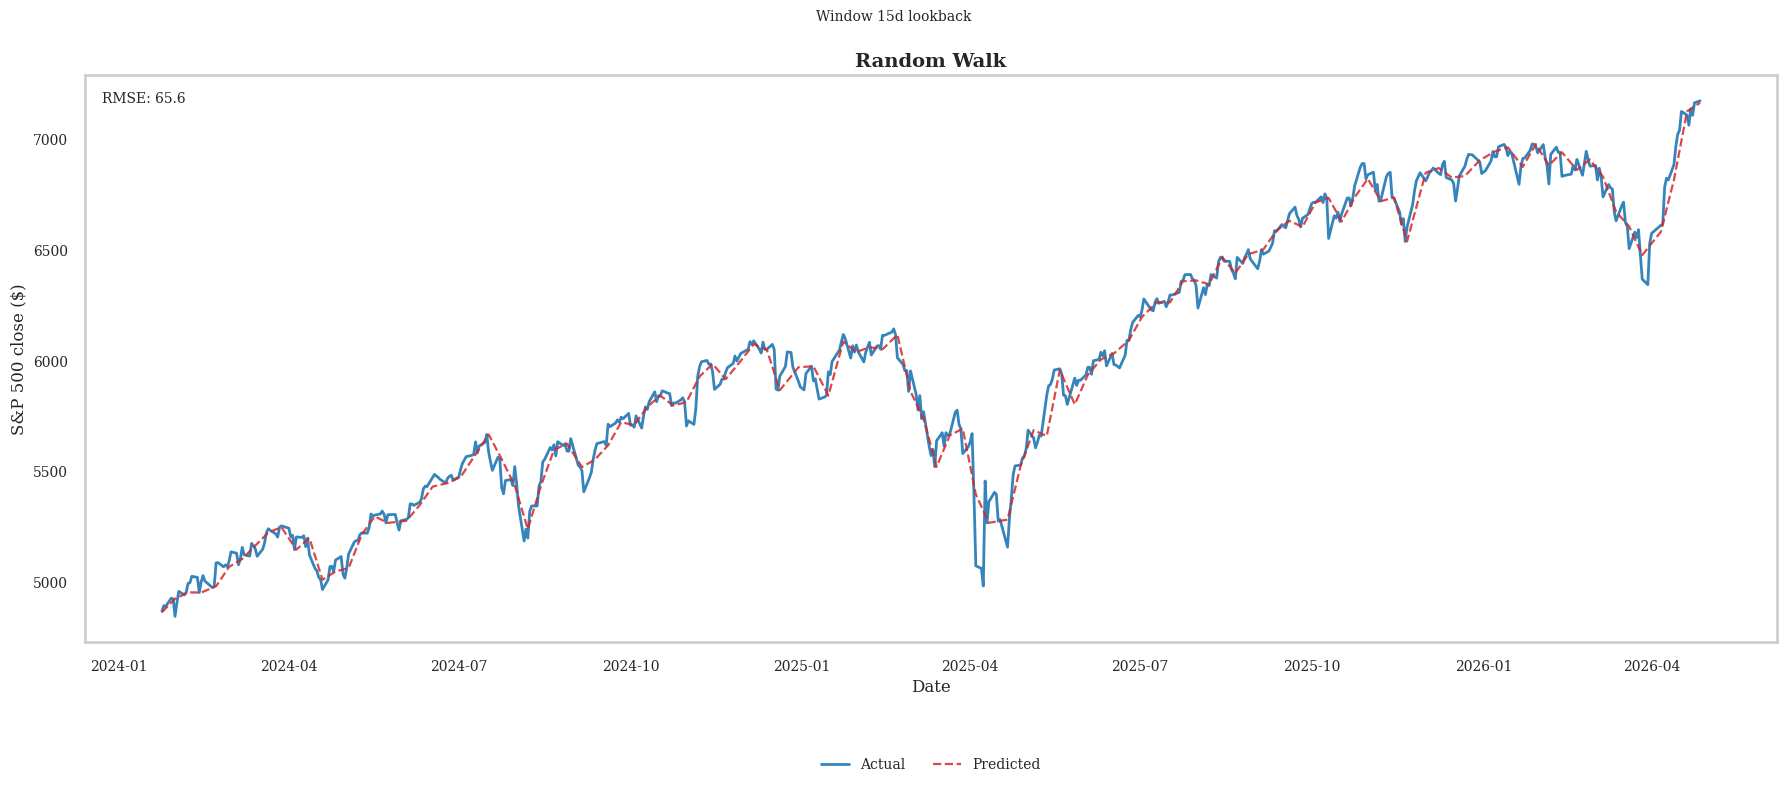

In [46]:
if dfs_d is not None and "random_walk" in dfs_d:
    ev = prep_eval(dfs_d["random_walk"])
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_actual_vs_pred(ax, ev, "Random Walk", "#d62728", full_daily=master_d)
    ax.set_xlabel("Date")
    plt.suptitle(f"Window {W_D}d lookback", fontsize=10, y=0.995)
    ax.grid(False)
    leg = ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25),
                    ncol=3, fontsize=10, frameon=False)
    plt.tight_layout()
    plt.savefig("daily_model_random_walk.png", dpi=150,
                bbox_inches="tight", bbox_extra_artists=[leg])
    plt.show()


#### AR(1) on log returns


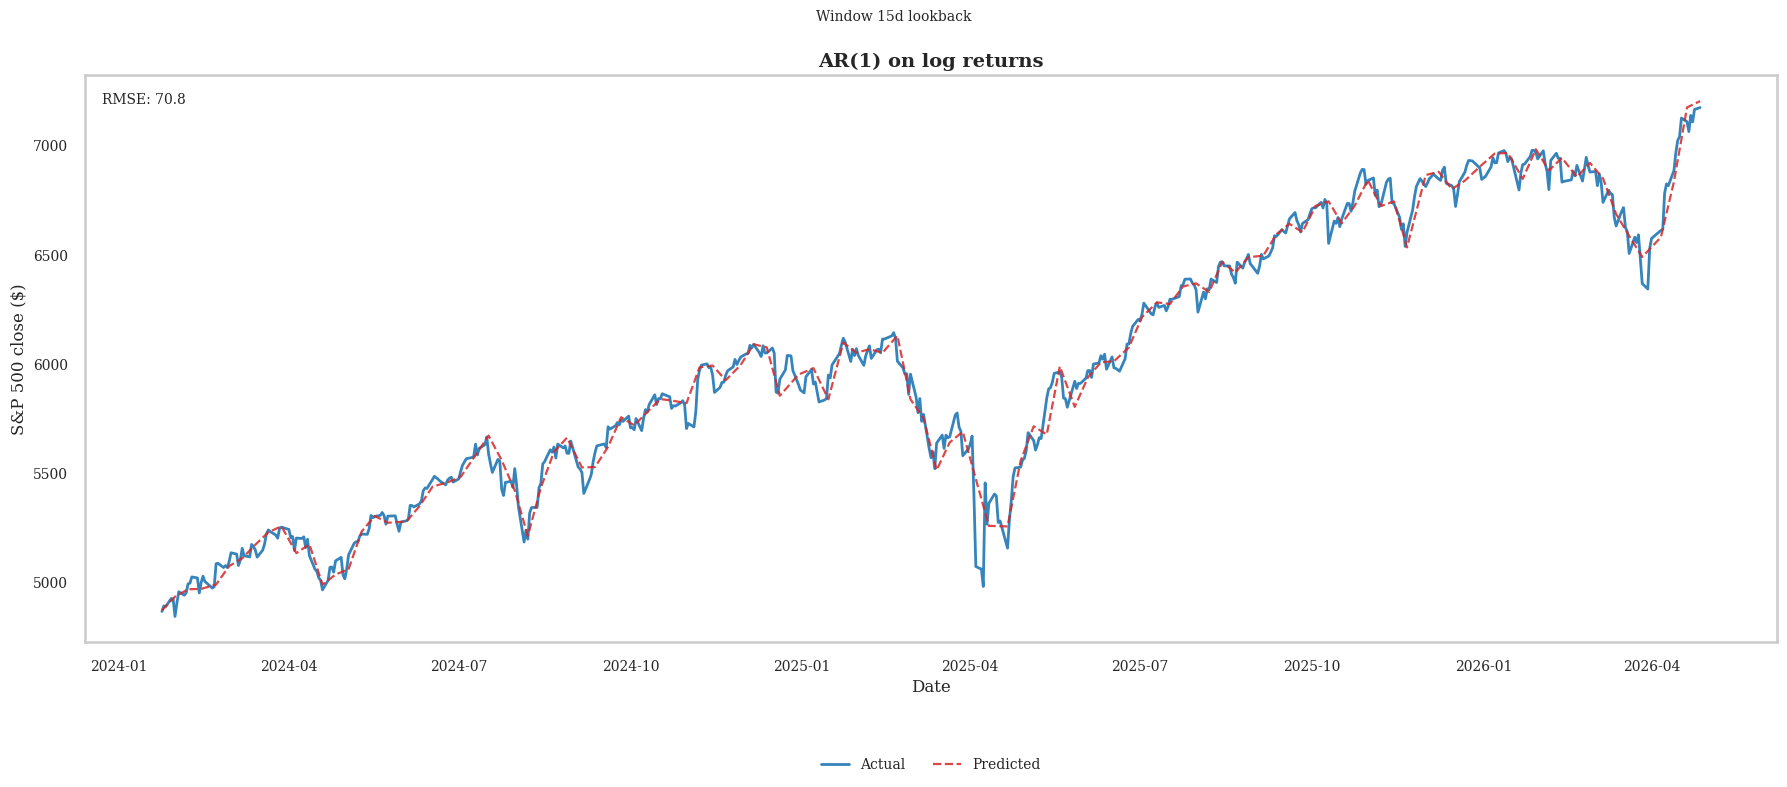

In [47]:
if dfs_d is not None and "ar1" in dfs_d:
    ev = prep_eval(dfs_d["ar1"])
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_actual_vs_pred(ax, ev, "AR(1) on log returns", "#d62728", full_daily=master_d)
    ax.set_xlabel("Date")
    plt.suptitle(f"Window {W_D}d lookback", fontsize=10, y=0.995)
    ax.grid(False)
    leg = ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25),
                ncol=3, fontsize=10, frameon=False)
    plt.tight_layout()
    plt.savefig("daily_model_ar1.png", dpi=150,
            bbox_inches="tight", bbox_extra_artists=[leg])
    plt.show()

#### ARIMAX with lag-1 attention


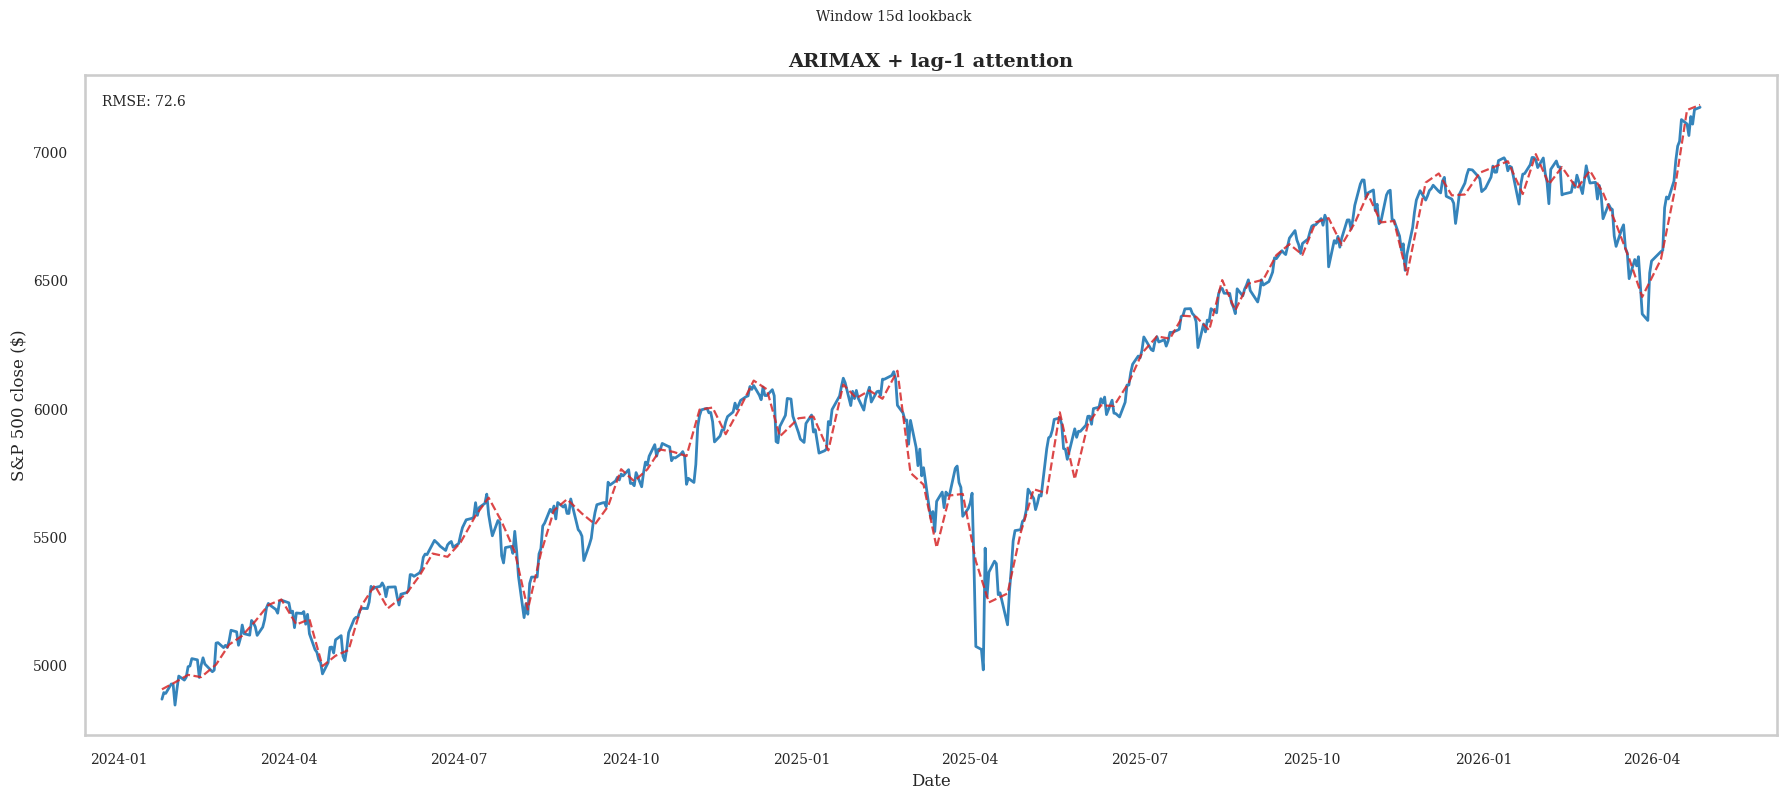

In [48]:
if dfs_d is not None and "arimax_attn" in dfs_d:
    ev = prep_eval(dfs_d["arimax_attn"])
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_actual_vs_pred(ax, ev, "ARIMAX + lag-1 attention", "#d62728", full_daily=master_d)
    ax.set_xlabel("Date")
    plt.suptitle(f"Window {W_D}d lookback", fontsize=10, y=0.995)
    plt.tight_layout()
    plt.savefig("daily_model_arimax.png", dpi=150, bbox_inches="tight")
    plt.show()

#### P1 — LLM, prices only (zero-shot)


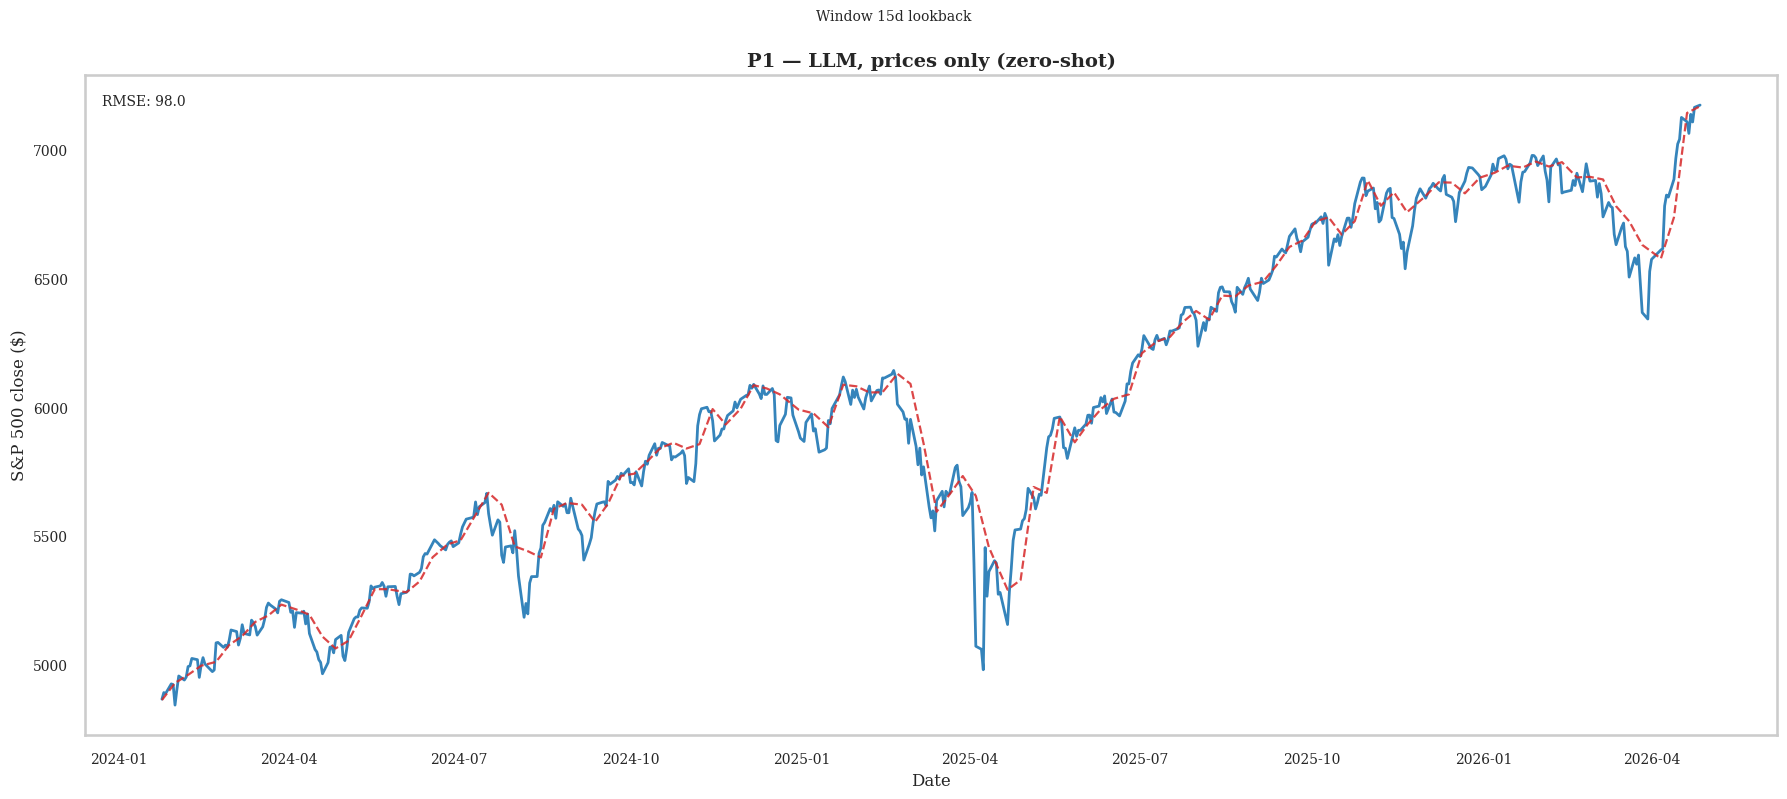

In [49]:
if dfs_d is not None and "p1" in dfs_d:
    ev = prep_eval(dfs_d["p1"])
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_actual_vs_pred(ax, ev, "P1 — LLM, prices only (zero-shot)", "#d62728", full_daily=master_d)
    ax.set_xlabel("Date")
    plt.suptitle(f"Window {W_D}d lookback", fontsize=10, y=0.995)
    plt.tight_layout()
    plt.savefig("daily_model_p1.png", dpi=150, bbox_inches="tight")
    plt.show()

#### P2 — LLM, prices + attention (zero-shot)


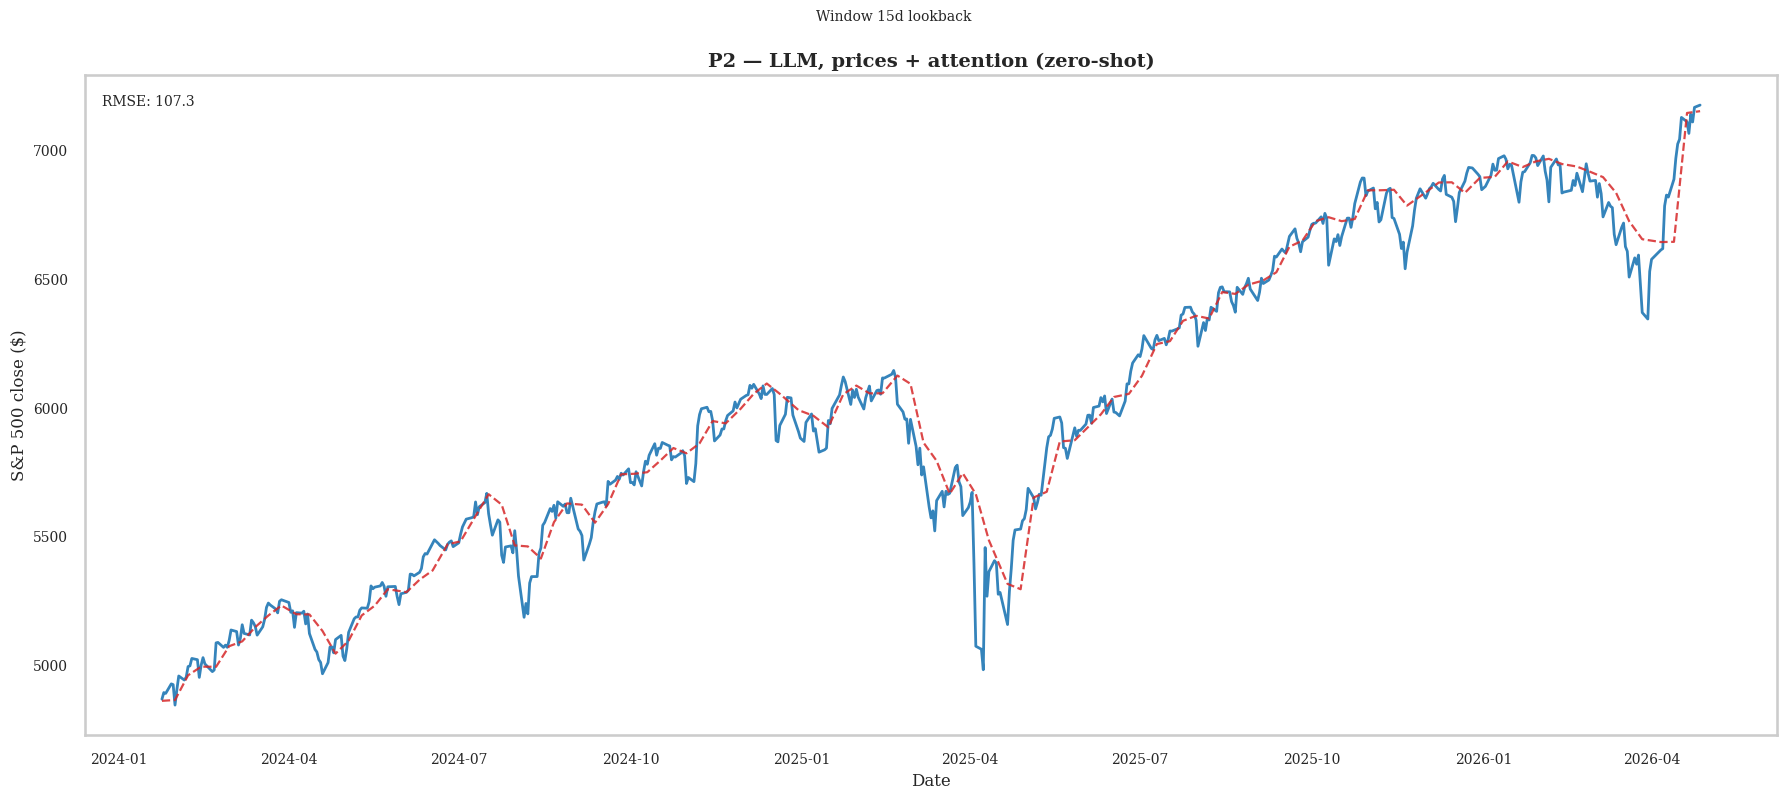

In [50]:
if dfs_d is not None and "p2" in dfs_d:
    ev = prep_eval(dfs_d["p2"])
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_actual_vs_pred(ax, ev, "P2 — LLM, prices + attention (zero-shot)", "#d62728", full_daily=master_d)
    ax.set_xlabel("Date")
    plt.suptitle(f"Window {W_D}d lookback", fontsize=10, y=0.995)
    plt.tight_layout()
    plt.savefig("daily_model_p2.png", dpi=150, bbox_inches="tight")
    plt.show()

#### P3 — LLM, prices + attention (few-shot)


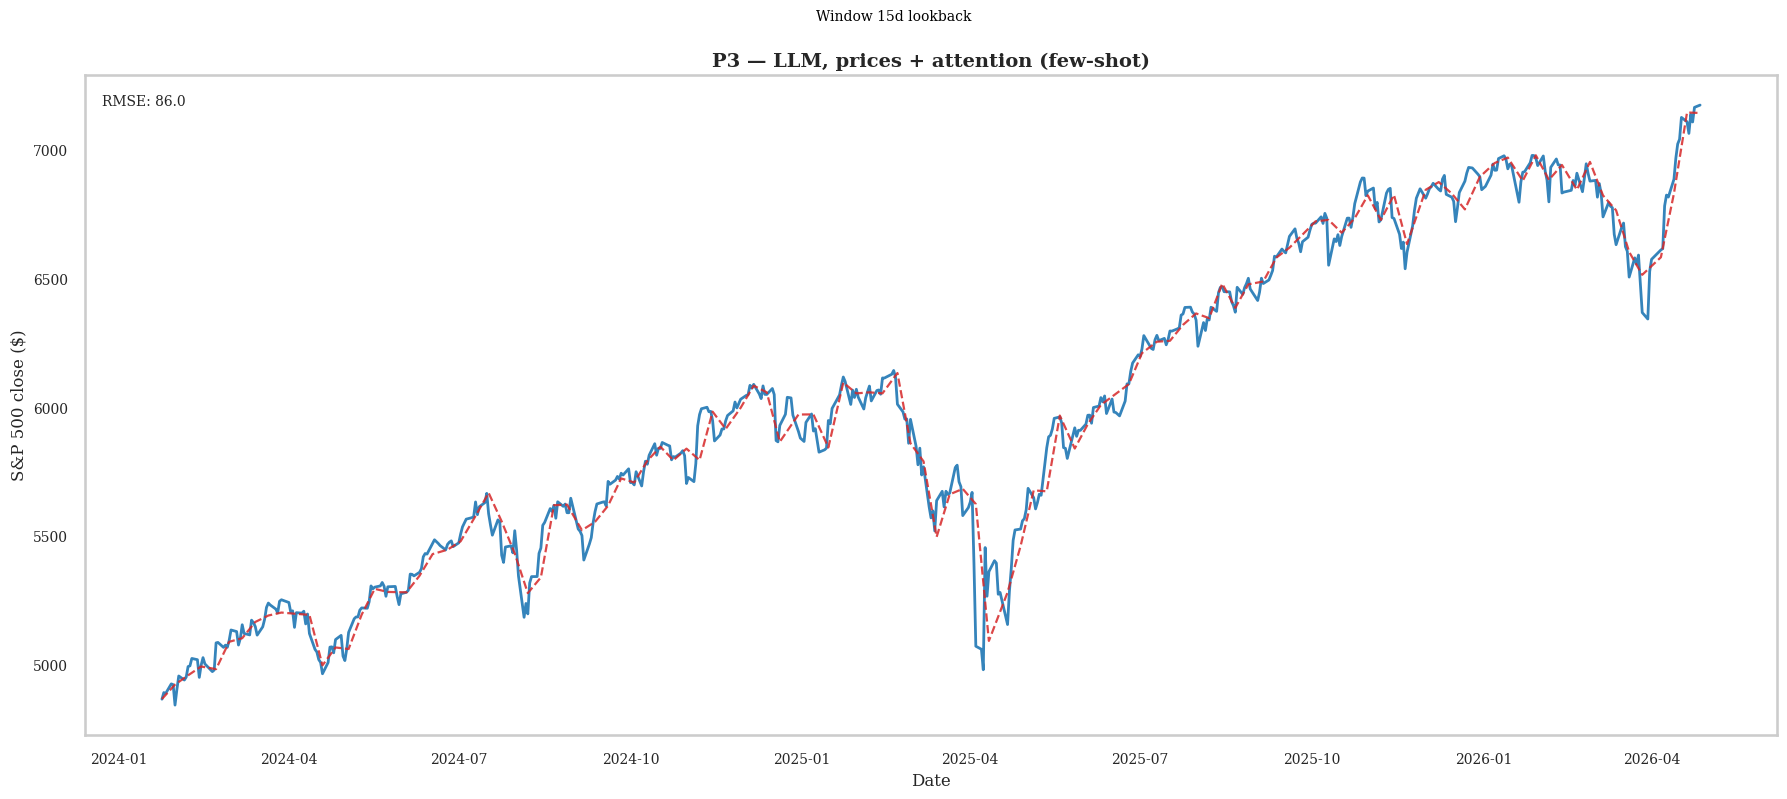

In [51]:
if dfs_d is not None and "p3" in dfs_d:
    ev = prep_eval(dfs_d["p3"])
    fig, ax = plt.subplots(figsize=(18, 8))
    plot_actual_vs_pred(ax, ev, "P3 — LLM, prices + attention (few-shot)", "#d62728", full_daily=master_d)
    ax.set_xlabel("Date")
    ax.set_facecolor("white")
    ax.grid(False)

    plt.suptitle(f"Window {W_D}d lookback", fontsize=10, y=0.995, color="black")
    plt.tight_layout()
    plt.savefig("daily_model_p3.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

## 15. Statistical significance of RMSE differences


* **Diebold–Mariano test** (Diebold & Mariano 1995) with the **Harvey–Leybourne–Newbold
  small-sample correction** — pairwise test of equal predictive accuracy.


In [52]:
from scipy import stats as sps

def diebold_mariano(e1: np.ndarray, e2: np.ndarray, h: int = 1) -> dict:
    """DM test with HLN small-sample correction. Squared-error loss.
    """
    d = e1 ** 2 - e2 ** 2
    T = len(d)
    mean_d = d.mean()
    # Long-run variance via Newey-West with h-1 lags (h=1 → just sample var)
    gamma0 = ((d - mean_d) ** 2).mean()
    var_d = gamma0
    for lag in range(1, h):
        w = 1 - lag / h
        gamma_k = ((d[lag:] - mean_d) * (d[:-lag] - mean_d)).mean()
        var_d += 2 * w * gamma_k
    if var_d <= 0:
        return {'dm_stat': np.nan, 'p_value': np.nan, 'mean_diff': mean_d}
    dm_stat = mean_d / np.sqrt(var_d / T)
    # Harvey-Leybourne-Newbold correction
    hln = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_stat *= hln
    p_value = 2 * (1 - sps.t.cdf(abs(dm_stat), df=T - 1))
    return {'dm_stat': dm_stat, 'p_value': p_value, 'mean_diff': mean_d}


if dfs_d is not None:
    # Align all model evaluations on the same date set (intersection).
    evs = {k: prep_eval(dfs_d[k]).set_index('date') for k in dfs_d}
    common_dates = set.intersection(*[set(e.index) for e in evs.values()])
    print(f"Common evaluation dates: {len(common_dates)}")
    evs = {k: e.loc[sorted(common_dates)] for k, e in evs.items()}

    # Pairs to test: each model vs random walk, AR(1), and P3 vs AR(1)
    pairs = [
        ('ar1',         'random_walk'),
        ('arimax_attn', 'random_walk'),
        ('p1',          'random_walk'),
        ('p2',          'random_walk'),
        ('p3',          'random_walk'),
        ('arimax_attn', 'ar1'),
        ('p1',          'ar1'),
        ('p2',          'ar1'),
        ('p3',          'ar1'),
        ('p3',          'p1'),
        ('p3',          'p2'),
    ]

    rows = []
    for m1, m2 in pairs:
        if m1 not in evs or m2 not in evs:
            continue
        e1 = evs[m1]['error_price'].values
        e2 = evs[m2]['error_price'].values
        dm   = diebold_mariano(e1, e2)
        rows.append({
            'Model A':    m1,
            'Model B':    m2,
            'ΔRMSE (A−B)': round(np.sqrt((e1**2).mean()) - np.sqrt((e2**2).mean()), 2),
            'DM stat':    round(dm['dm_stat'], 3),
            'DM p-value': round(dm['p_value'], 4),
        })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("Run the daily experiment first — dfs_d is None.")


Common evaluation dates: 114
    Model A     Model B  ΔRMSE (A−B)  DM stat  DM p-value
        ar1 random_walk         5.17    1.362      0.1758
arimax_attn random_walk         6.98    2.207      0.0293
         p1 random_walk        32.33    2.339      0.0211
         p2 random_walk        41.70    2.956      0.0038
         p3 random_walk        20.40    1.658      0.1002
arimax_attn         ar1         1.80    0.429      0.6689
         p1         ar1        27.16    2.505      0.0137
         p2         ar1        36.52    3.194      0.0018
         p3         ar1        15.23    1.688      0.0942
         p3          p1       -11.93   -1.949      0.0538
         p3          p2       -21.29   -3.048      0.0029


## 16. April 2025 — six-model overlay

All six models plotted on the same axes around the April 2025 drawdown.


In [53]:
# A. Per-model performance over the volatile window (Feb-Jun 2025)
window = (pd.Timestamp('2025-02-01'), pd.Timestamp('2025-06-30'))

if dfs_d is not None:
    rows = []
    for m_name, df in dfs_d.items():
        ev = prep_eval(df)
        ev = ev[(ev['date'] >= window[0]) & (ev['date'] <= window[1])]
        if len(ev) == 0:
            continue
        m = compute_metrics(ev, m_name)
        rows.append({
            'Model':  m_name,
            'n':      m['n'],
            'RMSE':   m['RMSE'],
            'R2':     m['R2'],
        })

    result_a = pd.DataFrame(rows).sort_values('RMSE')
    print("=" * 70)
    print(f"PERFORMANCE OVER VOLATILE WINDOW: {window[0].date()} -> {window[1].date()}")
    print("=" * 70)
    print(result_a.to_string(index=False))
    result_a.to_csv("metrics_april2025.csv", index=False)
else:
    print("Run the daily experiment first — dfs_d is None.")

PERFORMANCE OVER VOLATILE WINDOW: 2025-02-01 -> 2025-06-30
      Model  n   RMSE     R2
random_walk 20 108.22 0.8697
        ar1 20 120.60 0.8382
arimax_attn 20 127.07 0.8204
         p3 20 157.64 0.7235
         p1 20 161.22 0.7108
         p2 20 171.75 0.6719


In [54]:
# B. Diebold-Mariano across model pairs, restricted to the volatile window
window = (pd.Timestamp('2025-02-01'), pd.Timestamp('2025-06-30'))

if dfs_d is not None:
    # Align all models on the same dates, then filter to the volatile window
    evs = {k: prep_eval(dfs_d[k]).set_index('date') for k in dfs_d}
    common_dates = set.intersection(*[set(e.index) for e in evs.values()])
    common_dates = sorted(d for d in common_dates if window[0] <= d <= window[1])
    print(f"Predictions in volatile window: {len(common_dates)}")

    if len(common_dates) < 5:
        print("Too few observations for a reliable test - interpret with caution.")

    evs = {k: e.loc[common_dates] for k, e in evs.items()}

    pairs = [
        ('p3', 'ar1'),
        ('p3', 'arimax_attn'),
        ('p3', 'random_walk'),
        ('ar1', 'random_walk'),
        ('arimax_attn', 'ar1'),
    ]

    rows = []
    for m1, m2 in pairs:
        if m1 not in evs or m2 not in evs:
            continue
        e1 = evs[m1]['error_price'].values
        e2 = evs[m2]['error_price'].values
        dm = diebold_mariano(e1, e2)
        rows.append({
            'Model A':    m1,
            'Model B':    m2,
            'RMSE A':     round(np.sqrt((e1 ** 2).mean()), 2),
            'RMSE B':     round(np.sqrt((e2 ** 2).mean()), 2),
            'DM stat':    round(dm['dm_stat'], 3),
            'DM p-value': round(dm['p_value'], 4),
        })

    result_b = pd.DataFrame(rows)
    print("\n" + "=" * 70)
    print(f"DIEBOLD-MARIANO OVER VOLATILE WINDOW: {window[0].date()} -> {window[1].date()}")
    print("=" * 70)
    print(result_b.to_string(index=False))
else:
    print("Run the daily experiment first — dfs_d is None.")

Predictions in volatile window: 20

DIEBOLD-MARIANO OVER VOLATILE WINDOW: 2025-02-01 -> 2025-06-30
    Model A     Model B  RMSE A  RMSE B  DM stat  DM p-value
         p3         ar1  157.64  120.60    1.341      0.1957
         p3 arimax_attn  157.64  127.07    0.830      0.4167
         p3 random_walk  157.64  108.22    1.268      0.2202
        ar1 random_walk  120.60  108.22    0.980      0.3396
arimax_attn         ar1  127.07  120.60    0.477      0.6386


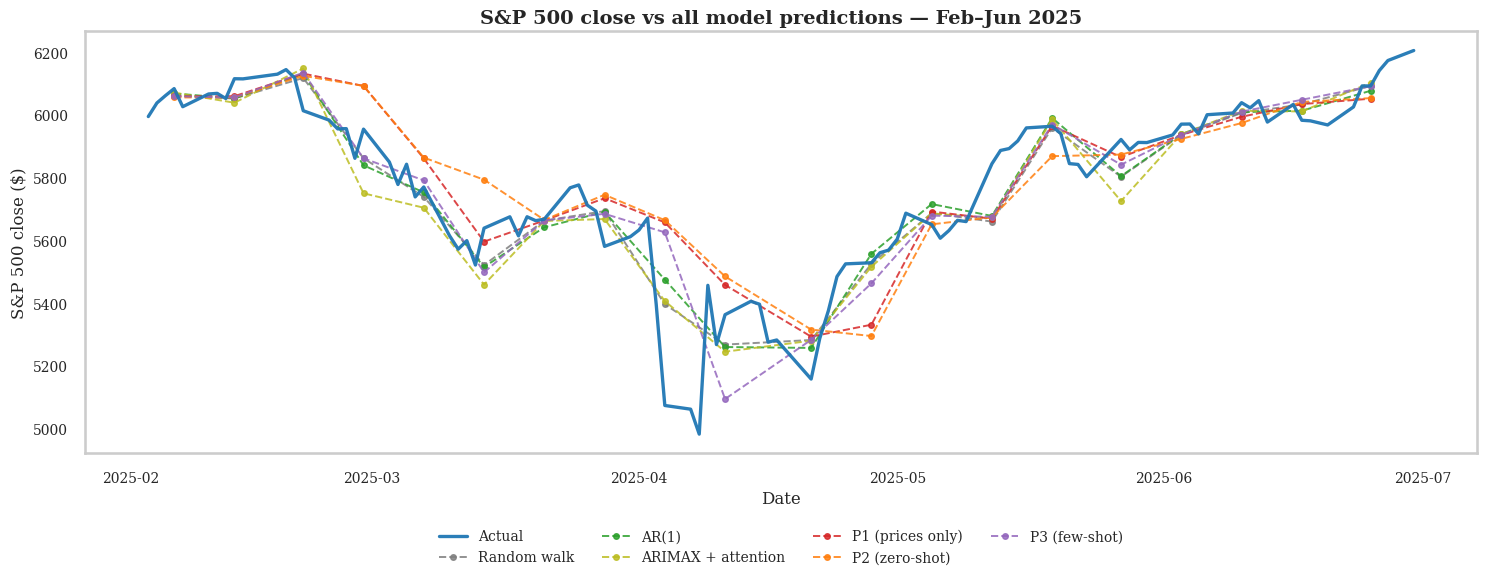

In [55]:
if dfs_d is not None:
    pretty = {
        'random_walk':  ('Random walk',          '#7f7f7f'),
        'ar1':          ('AR(1)',                '#2ca02c'),
        'arimax_attn':  ('ARIMAX + attention',   '#bcbd22'),
        'p1':           ('P1 (prices only)',     '#d62728'),
        'p2':           ('P2 (zero-shot)',       '#ff7f0e'),
        'p3':           ('P3 (few-shot)',        '#9467bd'),
    }

    window = (pd.Timestamp('2025-02-01'), pd.Timestamp('2025-06-30'))

    fig, ax = plt.subplots(figsize=(15, 6), facecolor='white')
    if master_d is not None:
        s = master_d.loc[window[0]:window[1], 'close']
        ax.plot(s.index, s.values, color='#1f77b4', lw=2.4,
                label='Actual', alpha=0.95, zorder=10)

    for k, (label, col) in pretty.items():
        if k not in dfs_d:
            continue
        ev = prep_eval(dfs_d[k]).sort_values('date')
        mask = (ev['date'] >= window[0]) & (ev['date'] <= window[1])
        ax.plot(ev.loc[mask, 'date'], ev.loc[mask, 'predicted'],
                color=col, lw=1.4, ls='--', alpha=0.85,
                label=label, marker='o', markersize=4)

    ax.set_title('S&P 500 close vs all model predictions — Feb–Jun 2025')
    ax.set_ylabel('S&P 500 close ($)')
    ax.set_xlabel('Date')

    ax.set_facecolor('white')
    ax.grid(False)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
              ncol=4, frameon=False)
    plt.tight_layout()
    plt.savefig('april2025_overlay.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

In [56]:
master_d.to_parquet('master_d.parquet')